Imports

In [25]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.model_selection import train_test_split

import torch
from torch.utils.data import Dataset, DataLoader

import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp

Define Dataset Paths

In [26]:
dataset_path = Path(r"C:\BITS AI ML\Project final\Vegetation_Encroachment_Project\data\raw\vep1\TESELLATED_WITHOUT_AUGMENTATION")

rgb_path = dataset_path / "RGB"
mask_path = dataset_path / "MASK"

rgb_images = sorted(list(rgb_path.glob("*")))
mask_images = sorted(list(mask_path.glob("*")))

print("RGB Images:", len(rgb_images))
print("Mask Images:", len(mask_images))


RGB Images: 532
Mask Images: 532


Train/Validation Split

In [16]:
from sklearn.model_selection import train_test_split

train_images, val_images, train_masks, val_masks = train_test_split(
    rgb_images,
    mask_images,
    test_size=0.2,
    random_state=42
)

print("Train Images:", len(train_images))
print("Validation Images:", len(val_images))

Train Images: 425
Validation Images: 107


Label Remapping

In [17]:
def remap_mask(mask):
    new_mask = np.zeros_like(mask)

    new_mask[mask == 0] = 0
    new_mask[mask == 110] = 1
    new_mask[mask == 149] = 2

    return new_mask

sample_mask = cv2.imread(str(train_masks[0]), cv2.IMREAD_GRAYSCALE)

new_mask = remap_mask(sample_mask)

print("Original values:", np.unique(sample_mask))
print("Remapped values:", np.unique(new_mask))

Original values: [  0 110 149]
Remapped values: [0 1 2]


Augmentations

In [18]:
import albumentations as A
from albumentations.pytorch import ToTensorV2

train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.Normalize(),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Normalize(),
    ToTensorV2()
])

PyTorch Dataset class

In [19]:
from torch.utils.data import Dataset

class VEPLDataset(Dataset):

    def __init__(self, image_paths, mask_paths, transform=None):
        self.image_paths = image_paths
        self.mask_paths = mask_paths
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = cv2.imread(str(self.image_paths[idx]))
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        mask = cv2.imread(str(self.mask_paths[idx]), cv2.IMREAD_GRAYSCALE)
        mask = remap_mask(mask)

        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented["image"]
            mask = augmented["mask"].long()

        return image, mask

Create Dataset Objects

In [20]:
train_dataset = VEPLDataset(
    train_images,
    train_masks,
    transform=train_transform
)

val_dataset = VEPLDataset(
    val_images,
    val_masks,
    transform=val_transform
)

print("Train dataset size:", len(train_dataset))
print("Validation dataset size:", len(val_dataset))

Train dataset size: 425
Validation dataset size: 107


Create DataLoaders

In [21]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=8,
    shuffle=False
)

print("DataLoaders created successfully!")

DataLoaders created successfully!


Verify Batch Loading

In [22]:
images, masks = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Mask batch shape:", masks.shape)

print("Image dtype:", images.dtype)
print("Mask dtype:", masks.dtype)

print("Unique mask values in batch:", torch.unique(masks))

Image batch shape: torch.Size([8, 3, 256, 256])
Mask batch shape: torch.Size([8, 256, 256])
Image dtype: torch.float32
Mask dtype: torch.int64
Unique mask values in batch: tensor([0, 1, 2])


Device Setup

In [23]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

Using device: cuda


Create U-Net Model

In [27]:
model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=3
)

model = model.to(device)

print("U-Net model created successfully")

config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

c:\Users\Bharat Govind\anaconda3\envs\powerline_ai\lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Bharat Govind\.cache\huggingface\hub\models--smp-hub--resnet34.imagenet. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

U-Net model created successfully


Define Loss and Optimizer

In [28]:
loss_fn = torch.nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4
)

print("Loss and optimizer ready")

Loss and optimizer ready


Train for 5 Epochs

In [29]:
num_epochs = 5

for epoch in range(num_epochs):
    model.train()
    train_loss = 0

    for images, masks in train_loader:
        images = images.to(device)
        masks = masks.to(device)

        outputs = model(images)
        loss = loss_fn(outputs, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    avg_train_loss = train_loss / len(train_loader)

    model.eval()
    val_loss = 0

    with torch.no_grad():
        for images, masks in val_loader:
            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)
            loss = loss_fn(outputs, masks)

            val_loss += loss.item()

    avg_val_loss = val_loss / len(val_loader)

    print(f"Epoch [{epoch+1}/{num_epochs}] Train Loss: {avg_train_loss:.4f} Val Loss: {avg_val_loss:.4f}")

Epoch [1/5] Train Loss: 0.7064 Val Loss: 0.5949
Epoch [2/5] Train Loss: 0.4844 Val Loss: 0.3862
Epoch [3/5] Train Loss: 0.4292 Val Loss: 0.3952
Epoch [4/5] Train Loss: 0.4275 Val Loss: 0.3746
Epoch [5/5] Train Loss: 0.4036 Val Loss: 0.3442


Save Model

In [30]:
torch.save(model.state_dict(), "../models/unet_vepl_baseline.pth")

print("Model saved successfully")

Model saved successfully


First Prediction

In [31]:
model.eval()

images, masks = next(iter(val_loader))
images = images.to(device)

with torch.no_grad():
    outputs = model(images)
    preds = torch.argmax(outputs, dim=1)

print("Prediction shape:", preds.shape)

Prediction shape: torch.Size([8, 256, 256])


Visualize Prediction

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.6399999].


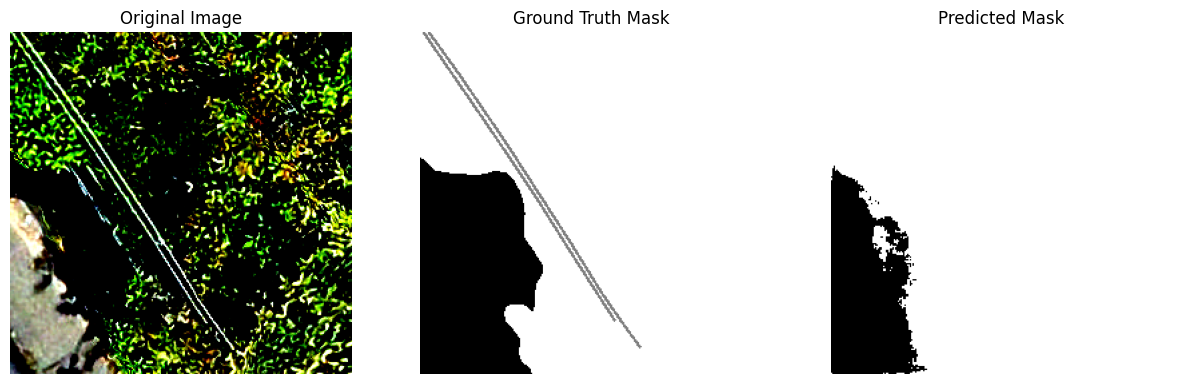

In [32]:
idx = 0

image = images[idx].cpu().permute(1, 2, 0)
mask = masks[idx].cpu()
pred = preds[idx].cpu()

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(mask, cmap="gray")
plt.title("Ground Truth Mask")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(pred, cmap="gray")
plt.title("Predicted Mask")
plt.axis("off")

plt.show()